# 03 - Spatial analysis: correlation, spatial autocorrelation and clusters

**Question.** Are demographic, economic and public-safety patterns geographically associated across Mexico City, and
where are the clusters?

**What this notebook does** (all data come from the warehouse view `dw.vw_ageb_kpis`):

1. Define the analysis sample and the **spatial-neighbourhood rule**.
2. Correlation between indicators (Spearman, with Pearson on log scale as a check).
3. **Global Moran's I** for four indicators (permutation inference).
4. **Local Moran's I (LISA)**: clusters and spatial outliers.
5. **Bivariate Moran's I**: do AGEB with many businesses have high-crime neighbours?
6. Robustness checks and interpretation cautions.

Spatial association does not imply causation. Every result below describes patterns, not causes.

In [1]:
import sys, warnings
from pathlib import Path

# make the project's src/ package importable when the notebook runs from notebooks/
SRC = Path.cwd().resolve().parent / "src"
sys.path.insert(0, str(SRC))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

import config
import viz
import spatial_analysis as sa
from db import get_engine

pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
pd.set_option("display.width", 140)

OUT = config.ROOT / "outputs"
MAPS, FIGS, TABLES = OUT / "maps", OUT / "figures", OUT / "tables"
for d in (MAPS, FIGS, TABLES):
    d.mkdir(parents=True, exist_ok=True)

engine = get_engine()   # connection settings come from the PG* variables in .env

## 1. Sample and neighbourhood rule

**Sample.** Per-resident rates are unstable when an AGEB has very few residents (a park, an industrial block, one building).
We keep AGEB with at least **500 residents** and complete indicators, as defined in `spatial_analysis.analysis_sample`.

**Neighbourhood rule (primary): Queen contiguity**, row-standardised. Two AGEB are neighbours if they share an edge or a vertex.
Each AGEB's lag is then the average of its touching neighbours. This fits an urban mosaic where adjacent areas interact, but
it has two implications: AGEB differ a lot in size (large peripheral AGEB have many more neighbours than small central ones),
and removing low-population AGEB leaves some without touching neighbours (islands), which receive no lag and drop out of the
local statistics.

**Sensitivity rule: 8 nearest neighbours (KNN)** between centroids. It gives every AGEB exactly 8 neighbours (no islands) and a
size-independent neighbourhood, so we repeat the global tests with it to check that conclusions do not depend on the rule.

In [2]:
kpi = sa.add_transforms(sa.load_kpis(engine))
sample = sa.analysis_sample(kpi)

w_queen = sa.queen_weights(sample)
w_knn = sa.knn_weights(sample, k=8)

weights_summary = pd.DataFrame({"Queen contiguity": sa.describe_weights(w_queen),
                                "KNN (k=8)": sa.describe_weights(w_knn)})
display(Markdown(f"AGEB in warehouse: **{len(kpi):,}**. In the analysis sample: **{len(sample):,}** "
                 f"({len(kpi) - len(sample)} dropped for having fewer than {sa.MIN_POP_FOR_RATES} residents or missing indicators)."))
weights_summary

('WARNING: ', 1199, ' is an island (no neighbors)')


AGEB in warehouse: **2,431**. In the analysis sample: **2,311** (120 dropped for having fewer than 500 residents or missing indicators).

,Queen contiguity,KNN (k=8)
n,"2,311.000","2,311.000"
islands,1.000,0.000
min_neighbors,0.000,8.000
mean_neighbors,5.690,8.000
max_neighbors,21.000,8.000


## 2. Correlations between indicators

Indicators are right-skewed (a few AGEB have very high density or crime rate), so **Spearman** (rank-based) is the primary
measure. Pearson on log1p-transformed values is reported as a check. Heavy overlap in the denominators is avoided on purpose:
crime rate (per resident) is paired with business *density* (per km2), not with businesses per resident, because two ratios
that share the same denominator correlate partly by construction.

In [3]:
LABELS = {
    "log_population_density_km2": "Population density (log)",
    "log_business_density_km2": "Business density (log)",
    "log_retail_density_km2": "Retail density (log)",
    "log_service_density_km2": "Service density (log)",
    "log_crime_rate_per_1000": "Crime rate per 1,000 (log)",
    "eap_rate_pct": "Economically active rate (%)",
    "share_60_plus_pct": "Share aged 60+ (%)",
    "share_under_18_pct": "Share under 18 (%)",
}
PAIRS = [
    ("log_business_density_km2", "log_population_density_km2"),
    ("log_crime_rate_per_1000", "log_business_density_km2"),
    ("log_crime_rate_per_1000", "eap_rate_pct"),
    ("log_crime_rate_per_1000", "share_60_plus_pct"),
    ("log_crime_rate_per_1000", "log_retail_density_km2"),
]
corr_pairs = sa.correlation_table(sample, PAIRS)
corr_pairs["x"] = corr_pairs.x.map(LABELS); corr_pairs["y"] = corr_pairs.y.map(LABELS)
corr_pairs.to_csv(TABLES / "correlation_pairs.csv", index=False)
corr_pairs

,x,y,n,spearman_rho,spearman_p,pearson_r,pearson_p
0,Business density (log),Population density (log),2311,0.390,0.000,0.443,0.000
1,"Crime rate per 1,000 (log)",Business density (log),2311,0.285,0.000,0.315,0.000
2,"Crime rate per 1,000 (log)",Economically active rate (%),2311,0.176,0.000,0.273,0.000
3,"Crime rate per 1,000 (log)",Share aged 60+ (%),2311,0.398,0.000,0.326,0.000
4,"Crime rate per 1,000 (log)",Retail density (log),2311,0.067,0.001,0.145,0.000


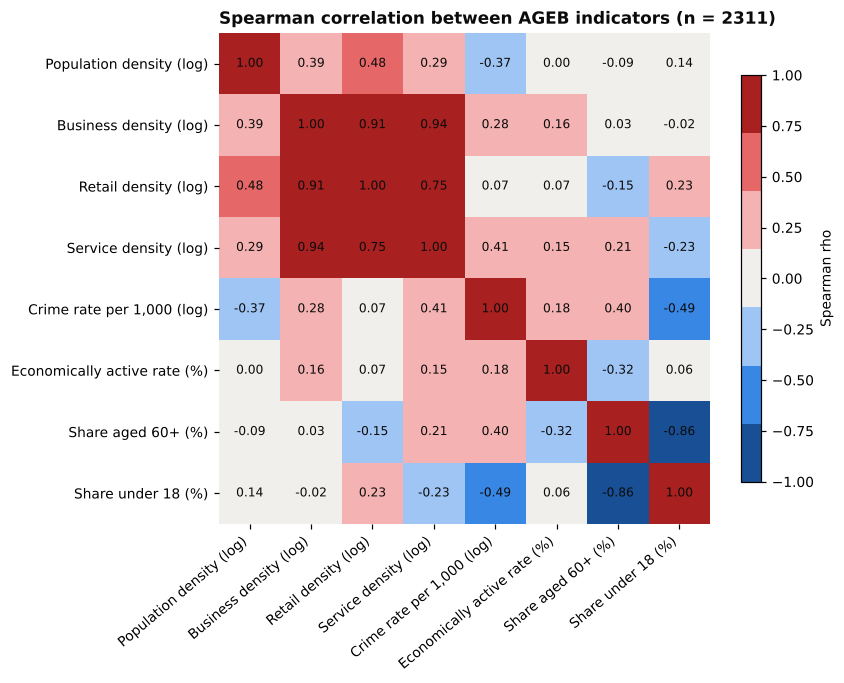

In [4]:
matrix = sample[list(LABELS)].corr(method="spearman").rename(index=LABELS, columns=LABELS)
matrix.to_csv(TABLES / "correlation_matrix_spearman.csv")
viz.correlation_heatmap(matrix, "Spearman correlation between AGEB indicators (n = %d)" % len(sample),
                        path=FIGS / "fig_correlation_heatmap.png")
plt.show()

In [5]:
r = corr_pairs.set_index(["x", "y"]).spearman_rho
display(Markdown(
    "**Reading the correlations.** "
    f"Business density and population density move together (rho = {r.iloc[0]:.2f}): businesses cluster where people live. "
    f"Crime rate is positively related to business density (rho = {r.iloc[1]:.2f}), a moderate link. "
    f"The links with the economically active rate (rho = {r.iloc[2]:.2f}) and retail density (rho = {r.iloc[4]:.2f}) are weak. "
    f"The share aged 60+ shows rho = {r.iloc[3]:.2f}, but its Pearson r is only {corr_pairs.pearson_r.iloc[3]:.2f}: the relation is rank-based "
    "and probably reflects older central neighbourhoods, which also have the most commerce and visitors (not tested here). All p-values are tiny because n is "
    "large, so look at the size of rho, not at significance."))

**Reading the correlations.** Business density and population density move together (rho = 0.39): businesses cluster where people live. Crime rate is positively related to business density (rho = 0.28), a moderate link. The links with the economically active rate (rho = 0.18) and retail density (rho = 0.07) are weak. The share aged 60+ shows rho = 0.40, but its Pearson r is only 0.33: the relation is rank-based and probably reflects older central neighbourhoods, which also have the most commerce and visitors (not tested here). All p-values are tiny because n is large, so look at the size of rho, not at significance.

## 3. Global Moran's I

Global Moran's I measures whether similar values sit next to each other (positive), alternate like a checkerboard (negative)
or are spatially random (near the expected value, about -1/(n-1)). Significance is a **permutation test** with 999 random
reshuffles; the smallest possible pseudo p-value is therefore 0.001.

In [6]:
INDICATORS = {
    "log_crime_rate_per_1000": "Crime rate per 1,000 (log)",
    "log_business_density_km2": "Business density (log)",
    "log_population_density_km2": "Population density (log)",
    "eap_rate_pct": "Economically active rate (%)",
}
rows = []
for col, label in INDICATORS.items():
    for rule, w in (("Queen", w_queen), ("KNN-8", w_knn)):
        res = sa.global_moran(sample[col], w, label)
        rows.append({**res.as_dict(), "weights": rule})
moran_global = pd.DataFrame(rows)[["indicator", "weights", "I", "E[I]", "z (permutation)", "p (permutation)"]]
moran_global.to_csv(TABLES / "moran_global.csv", index=False)
moran_global

,indicator,weights,I,E[I],z (permutation),p (permutation)
0,"Crime rate per 1,000 (log)",Queen,0.492,-0.000,37.731,0.001
1,"Crime rate per 1,000 (log)",KNN-8,0.451,-0.000,44.789,0.001
2,Business density (log),Queen,0.425,-0.000,32.579,0.001
3,Business density (log),KNN-8,0.373,-0.000,36.067,0.001
4,Population density (log),Queen,0.491,-0.000,38.366,0.001
5,Population density (log),KNN-8,0.468,-0.000,47.514,0.001
6,Economically active rate (%),Queen,0.530,-0.000,39.888,0.001
7,Economically active rate (%),KNN-8,0.498,-0.000,47.847,0.001


In [7]:
q = moran_global[moran_global.weights == "Queen"].set_index("indicator")
display(Markdown(
    f"**Reading Global Moran's I.** All four indicators show strong positive spatial autocorrelation "
    f"(Queen: I from {q.I.min():.2f} to {q.I.max():.2f}, expected value near 0, all pseudo p = {q['p (permutation)'].max():.3f}). "
    f"Crime rate has I = {q.loc['Crime rate per 1,000 (log)', 'I']:.2f}: AGEB with high crime rates tend to be surrounded by AGEB with high rates. "
    "The KNN-8 results give the same sign and a similar size, so the conclusion does not depend on the neighbourhood rule. "
    "Note that part of this clustering is expected simply because the city is organised in zones (a centre, residential belts, "
    "an industrial north-east)."))

**Reading Global Moran's I.** All four indicators show strong positive spatial autocorrelation (Queen: I from 0.43 to 0.53, expected value near 0, all pseudo p = 0.001). Crime rate has I = 0.49: AGEB with high crime rates tend to be surrounded by AGEB with high rates. The KNN-8 results give the same sign and a similar size, so the conclusion does not depend on the neighbourhood rule. Note that part of this clustering is expected simply because the city is organised in zones (a centre, residential belts, an industrial north-east).

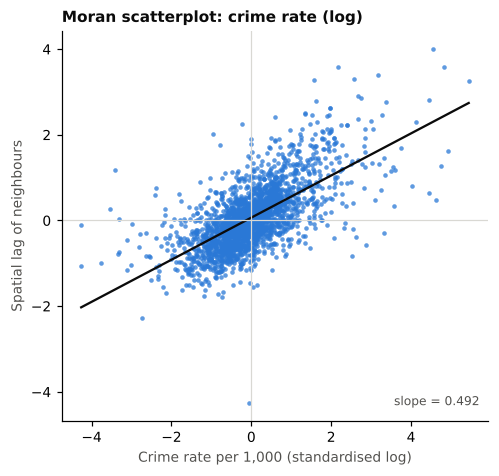

In [8]:
lag_crime = sa.spatial_lag(sample.log_crime_rate_per_1000, w_queen)
viz.moran_scatter(sample.log_crime_rate_per_1000, lag_crime,
                  "Moran scatterplot: crime rate (log)", path=FIGS / "fig_moran_scatter_crime_rate.png",
                  xlabel="Crime rate per 1,000 (standardised log)")
plt.show()

## 4. Local Moran's I (LISA): clusters and spatial outliers

LISA assigns each AGEB to a quadrant:

* **High-High**: high value surrounded by high values (hot spot).
* **Low-Low**: low value surrounded by low values (cold spot).
* **High-Low**: high value surrounded by low values (spatial outlier).
* **Low-High**: low value surrounded by high values (spatial outlier).

An AGEB is labelled only when its pseudo p-value is below 0.05 (two-sided, 999 permutations); otherwise it is *not significant*.
With ~2,300 simultaneous local tests, some labels will be false positives, so read the map as exploratory.

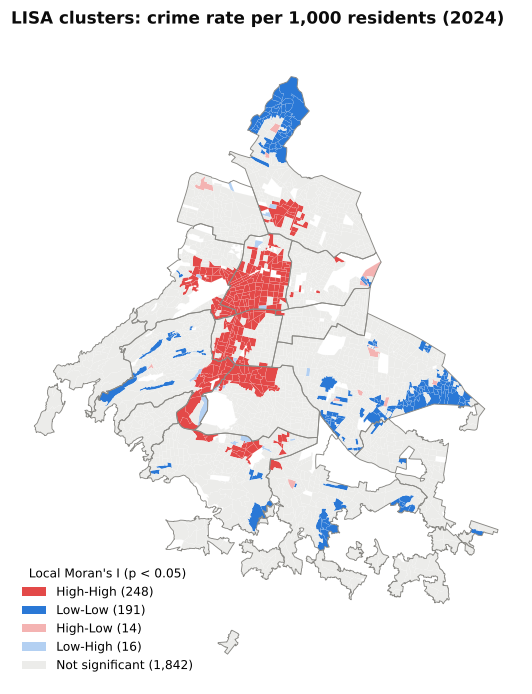

,AGEB
cluster,
High-High,248
Low-Low,191
High-Low,14
Low-High,16
Not significant,1842


In [9]:
alcaldias = kpi.dissolve(by="cve_mun")[["geometry"]]
lisa_crime = sa.local_moran(sample.log_crime_rate_per_1000, w_queen)
sample_lisa = pd.concat([sample, lisa_crime.add_prefix("crime_")], axis=1)

viz.categorical_map(sample_lisa, "crime_cluster", "LISA clusters: crime rate per 1,000 residents (2024)",
                    viz.CLUSTER_COLORS, path=MAPS / "map_lisa_crime_rate.png", boundaries=alcaldias,
                    legend_title="Local Moran's I (p < 0.05)")
plt.show()
sa.cluster_counts(lisa_crime.cluster).to_frame("AGEB")

In [10]:
hh = (sample_lisa[sample_lisa.crime_cluster == "High-High"].groupby("nom_mun").size()
      .sort_values(ascending=False).rename("High-High AGEB"))
share = (hh / sample_lisa.groupby("nom_mun").size()).dropna().rename("share of the alcaldia's AGEB")
hot = pd.concat([hh, share], axis=1).sort_values("High-High AGEB", ascending=False)
hot.to_csv(TABLES / "lisa_crime_hotspots_by_alcaldia.csv")
hot.head(8)

,High-High AGEB,share of the alcaldia's AGEB
nom_mun,,
Cuauhtémoc,95,0.669
Benito Juárez,44,0.436
Miguel Hidalgo,27,0.248
Coyoacán,23,0.150
Gustavo A. Madero,21,0.070
Tlalpan,16,0.084
Álvaro Obregón,16,0.084
Venustiano Carranza,4,0.029


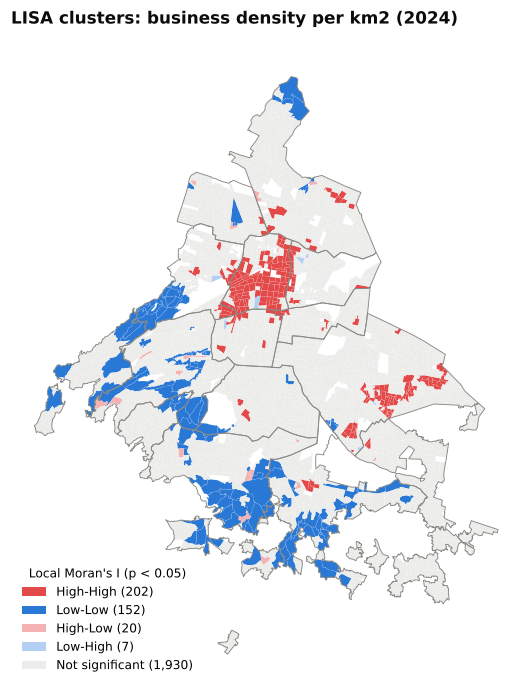

,crime rate,business density
cluster,,
High-High,248,202
Low-Low,191,152
High-Low,14,20
Low-High,16,7
Not significant,1842,1930


In [11]:
lisa_biz = sa.local_moran(sample.log_business_density_km2, w_queen)
sample_lisa = pd.concat([sample_lisa, lisa_biz.add_prefix("biz_")], axis=1)
viz.categorical_map(sample_lisa, "biz_cluster", "LISA clusters: business density per km2 (2024)",
                    viz.CLUSTER_COLORS, path=MAPS / "map_lisa_business_density.png", boundaries=alcaldias,
                    legend_title="Local Moran's I (p < 0.05)")
plt.show()
counts = pd.DataFrame({"crime rate": sa.cluster_counts(lisa_crime.cluster),
                       "business density": sa.cluster_counts(lisa_biz.cluster)})
counts.to_csv(TABLES / "lisa_counts.csv")
counts

In [12]:
overlap = pd.crosstab(sample_lisa.crime_cluster, sample_lisa.biz_cluster)
both_hh = overlap.loc["High-High", "High-High"]
hh_crime = (sample_lisa.crime_cluster == "High-High").sum()
display(Markdown(
    f"**Reading LISA.** There are {counts.loc['High-High', 'crime rate']} crime hot spots and {counts.loc['Low-Low', 'crime rate']} cold spots, "
    f"and only {counts.loc['High-Low', 'crime rate'] + counts.loc['Low-High', 'crime rate']} spatial outliers: the pattern is dominated by large "
    f"coherent zones. The hot spots concentrate in the central alcaldias (see table above). Of the {hh_crime} crime hot spots, "
    f"{both_hh} ({both_hh / hh_crime:.0%}) are also hot spots of business density, so commercial areas and high per-resident crime overlap spatially. "
    "A caution: central AGEB host many non-resident visitors, which inflates their per-resident rate."))
overlap

**Reading LISA.** There are 248 crime hot spots and 191 cold spots, and only 30 spatial outliers: the pattern is dominated by large coherent zones. The hot spots concentrate in the central alcaldias (see table above). Of the 248 crime hot spots, 91 (37%) are also hot spots of business density, so commercial areas and high per-resident crime overlap spatially. A caution: central AGEB host many non-resident visitors, which inflates their per-resident rate.

biz_cluster,High-High,High-Low,Low-High,Low-Low,Not significant
crime_cluster,,,,,
High-High,91,0,3,6,148
High-Low,2,0,0,1,11
Low-High,0,0,0,2,14
Low-Low,15,3,1,29,143
Not significant,94,17,3,114,1614


## 5. Bivariate spatial relationship

**Bivariate Moran's I** relates one variable at a location to a *different* variable in the neighbouring locations. Here:
**business density** (x, at the AGEB) against **crime rate** (y, in the surrounding AGEB). A positive value means AGEB with many
businesses tend to be surrounded by AGEB with high crime rates. The local version flags where this happens, and the bivariate
choropleth shows the two variables together without any statistics.

In [13]:
x, y = sample.log_business_density_km2, sample.log_crime_rate_per_1000
bv_rows = []
for rule, w in (("Queen", w_queen), ("KNN-8", w_knn)):
    res = sa.bivariate_moran(x, y, w, "Business density (x) vs crime rate in neighbours (y)")
    bv_rows.append({**res.as_dict(), "weights": rule})
bv = pd.DataFrame(bv_rows)[["indicator", "weights", "I", "E[I]", "z (permutation)", "p (permutation)"]]
bv.to_csv(TABLES / "moran_bivariate.csv", index=False)
bv

,indicator,weights,I,E[I],z (permutation),p (permutation)
0,Business density (x) vs crime rate in neighbou...,Queen,0.189,-0.000,11.919,0.001
1,Business density (x) vs crime rate in neighbou...,KNN-8,0.171,-0.000,12.490,0.001


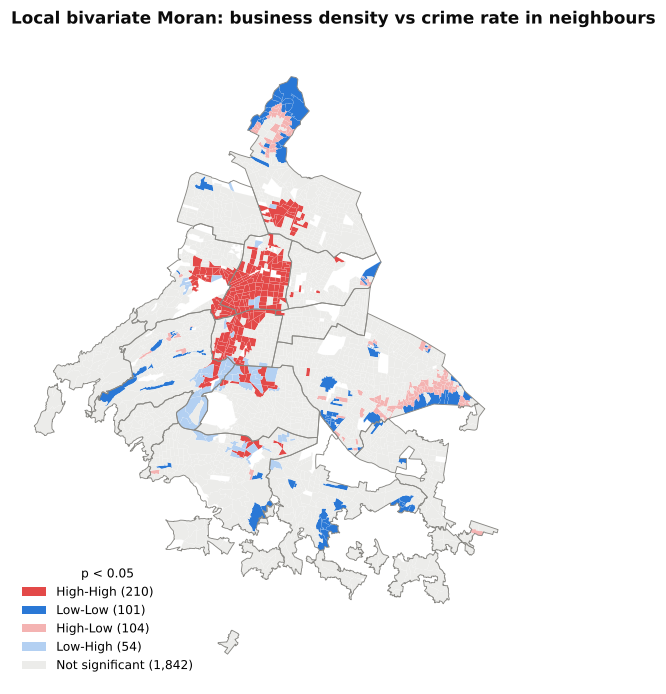

,AGEB
cluster,
High-High,210
Low-Low,101
High-Low,104
Low-High,54
Not significant,1842


In [14]:
lisa_bv = sa.local_bivariate(x, y, w_queen)
sample_lisa = pd.concat([sample_lisa, lisa_bv.add_prefix("bv_")], axis=1)
viz.categorical_map(sample_lisa, "bv_cluster",
                    "Local bivariate Moran: business density vs crime rate in neighbours",
                    viz.CLUSTER_COLORS, path=MAPS / "map_local_bivariate_moran.png", boundaries=alcaldias,
                    legend_title="p < 0.05")
plt.show()
bv_counts = sa.cluster_counts(lisa_bv.cluster).to_frame("AGEB"); bv_counts.to_csv(TABLES / "lisa_bivariate_counts.csv"); bv_counts

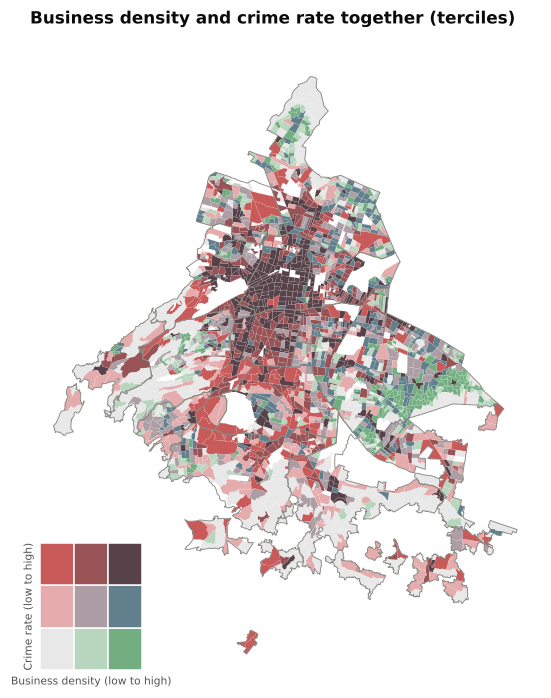

**Reading bivariate Moran.** I = 0.19 (z = 11.9, pseudo p = 0.001) with Queen weights; KNN-8 gives 0.17. The relationship is positive and significant but moderate: business density explains only part of where per-resident crime is high. 210 AGEB are bivariate hot spots (dense commerce surrounded by high crime) and they sit mostly in the central belt.

In [15]:
viz.bivariate_map(sample, "business_density_km2", "crime_rate_per_1000",
                  "Business density and crime rate together (terciles)", "Business density", "Crime rate",
                  path=MAPS / "map_bivariate_choropleth.png", boundaries=alcaldias)
plt.show()
b = bv[bv.weights == "Queen"].iloc[0]
display(Markdown(
    f"**Reading bivariate Moran.** I = {b.I:.2f} (z = {b['z (permutation)']:.1f}, pseudo p = {b['p (permutation)']:.3f}) with Queen weights; "
    f"KNN-8 gives {bv[bv.weights == 'KNN-8'].I.iloc[0]:.2f}. The relationship is positive and significant but moderate: "
    f"business density explains only part of where per-resident crime is high. {bv_counts.loc['High-High', 'AGEB']} AGEB are bivariate hot spots "
    "(dense commerce surrounded by high crime) and they sit mostly in the central belt."))

## 6. Robustness: smoothing small populations

Instead of dropping small-population AGEB, an **Empirical Bayes** smoother shrinks unstable rates toward the citywide mean
in proportion to their population. We recompute Global Moran's I for the smoothed crime rate on **all** AGEB.

In [16]:
from esda.smoothing import Empirical_Bayes
all_ageb = kpi[kpi.total_population > 0].reset_index(drop=True)
eb = Empirical_Bayes(all_ageb.total_crimes.values.astype(float), all_ageb.total_population.values.astype(float))
all_ageb["crime_rate_eb"] = np.log1p(eb.r * 1000)
w_all = sa.queen_weights(all_ageb)
res_eb = sa.global_moran(all_ageb.crime_rate_eb, w_all, "Crime rate, Empirical Bayes smoothed (all AGEB)")
robust = pd.DataFrame([res_eb.as_dict()])
robust.to_csv(TABLES / "moran_robustness_empirical_bayes.csv", index=False)
display(Markdown(f"With {len(all_ageb):,} AGEB and smoothed rates, Moran's I = **{res_eb.statistic:.2f}** "
                 f"(pseudo p = {res_eb.p_value:.3f}), consistent with the main result."))
robust

('WARNING: ', 1222, ' is an island (no neighbors)')


With 2,414 AGEB and smoothed rates, Moran's I = **0.37** (pseudo p = 0.001), consistent with the main result.

,indicator,I,E[I],z (permutation),p (permutation),permutations
0,"Crime rate, Empirical Bayes smoothed (all AGEB)",0.370,-0.000,31.329,0.001,999


In [17]:
export = sample_lisa[["cvegeo", "nom_mun", "crime_cluster", "crime_local_I", "crime_p_sim",
                      "biz_cluster", "bv_cluster"]]
export.to_csv(TABLES / "lisa_clusters_by_ageb.csv", index=False)
print(f"{len(export):,} AGEB with cluster labels written to outputs/tables/lisa_clusters_by_ageb.csv")

2,311 AGEB with cluster labels written to outputs/tables/lisa_clusters_by_ageb.csv


## 7. Interpretation cautions

* **Association is not causation.** The maps show where patterns coincide, not why. Commerce, visitors, reporting habits and
  policing all differ between zones.
* **Denominator problem.** Crime per resident uses the night-time population from Census 2020. Central AGEB receive large daytime
  populations, which inflates their rate. A rate per business or per visitor would change the picture.
* **Different years.** Population is 2020, businesses and crime are 2024 (a 4-year gap). Neighbourhoods that grew or emptied since 2020 are misrepresented.
* **Crime is recorded crime.** The data are investigation files (carpetas) filed with the prosecutor's office, not all crimes. Reporting
  rates differ between areas. About 6% of 2024 files had no coordinates and are excluded; times of day are heaped on round hours.
* **Modifiable areal unit problem.** AGEB are an administrative unit. Different boundaries (blocks, grids, alcaldias) would give different numbers.
* **Neighbourhood rule matters.** Queen contiguity gives large AGEB more neighbours than small ones; KNN-8 was used as a check and agrees.
* **Multiple testing.** LISA runs one test per AGEB and no correction is applied, so isolated labels can be false positives; the large coherent zones are the reliable signal.